In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import f1_score, r2_score, balanced_accuracy_score
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.neighbors import KNeighborsClassifier

In [2]:
df_moves = pd.read_csv('../data/all_processed_moves.csv')
df_games = pd.read_csv('../data/clear_data.csv')
GAME_COUNT = 4702

In [3]:
df_games.head()

,Events,results,white_elo,black_elo,white_rating_diff,black_rating_diff,ecos,openings,time_control,termination,game_id
0,Rated Classical game,1-0,1639,1403,5,-8,C00,French Defense: Normal Variation,600+8,Normal,0
1,Rated Classical game,1-0,1654,1919,19,-22,D04,"Queen's Pawn Game: Colle System, Anti-Colle",480+2,Normal,1
2,Rated Classical game,1-0,1643,1747,13,-94,C50,Four Knights Game: Italian Variation,420+17,Normal,2
3,Rated Bullet game,0-1,1824,1973,-6,8,B12,Caro-Kann Defense: Goldman Variation,60+1,Normal,3
4,Rated Bullet game,0-1,1765,1815,-9,9,C00,French Defense: La Bourdonnais Variation,60+1,Normal,4


In [4]:
df_moves.head()

,move,win,draw,lose,centipawns,moves_to_force_mate,best_line_1_move,best_line_1_centipawns,best_line_1_moves_to_force_mate,best_line_2_move,best_line_2_centipawns,best_line_2_moves_to_force_mate,best_line_3_move,best_line_3_centipawns,best_line_3_moves_to_force_mate,game_id,move_number
0,e2e4,0.020,0.900,0.080,33.0,NaN,e2e4,44.0,NaN,d2d4,33.0,NaN,g1f3,24.0,NaN,0,0
1,e7e6,0.093,0.890,0.017,41.0,NaN,c7c5,32.0,NaN,e7e5,43.0,NaN,e7e6,52.0,NaN,0,1
2,d2d4,0.014,0.878,0.108,49.0,NaN,d2d4,27.0,NaN,b1c3,27.0,NaN,g1f3,15.0,NaN,0,2
3,b7b6,0.275,0.721,0.004,101.0,NaN,d7d5,57.0,NaN,a7a6,76.0,NaN,h7h6,107.0,NaN,0,3
4,a2a3,0.008,0.826,0.166,71.0,NaN,g1f3,105.0,NaN,f1d3,101.0,NaN,c2c3,100.0,NaN,0,4


Давайте сначала попробуем обучить модель для белых. Понятно что для каждой игры мы хотим выделить фичей из совокупности ходов. Но сначала подумаем про категориальныне признаки

In [5]:
df_games['termination'].value_counts()

termination
Normal          2995
Time forfeit    1707
Name: count, dtype: int64

In [6]:
df_games['Events'].value_counts()

Events
Rated Bullet game                                                 1946
Rated Blitz game                                                  1625
Rated Classical game                                              1118
Rated Correspondence game                                            9
Rated Blitz tournament https://lichess.org/tournament/o9rl1qhx       4
Name: count, dtype: int64

Пусть пока нас не будет интересовать временной контроль. Для простоты попробуем обучиться просто по событиям, отбросив турниры и Correspondece game

In [7]:
df_games = df_games[(df_games.Events == 'Rated Bullet game') | (df_games.Events == 'Rated Classical game') | (
        df_games.Events == 'Rated Blitz game')]

Возьмем наши фичи из прошлой попытки, их тоже добавим в модель

In [8]:
from modules.utils.find_statistics import percent_best_move, min_centipawns_white, max_centipawns_white, \
    median_centipawns_white, win_mean, draw_mean

Добавим несколько фич и колонку с классом, который мы хотим угадывать для игрока

In [9]:
from modules.utils.rating_to_category import rating_to_number_easy

df_games['white_rating_num'] = df_games['white_elo'].apply(rating_to_number_easy)

df_games['white_percent_best_move'] = df_games['game_id'].apply(percent_best_move)
df_games['min_delta_centipawns_white'] = df_games['game_id'].apply(min_centipawns_white)
df_games['max_delta_centipawns_white'] = df_games['game_id'].apply(max_centipawns_white)
df_games['median_centipawns_white'] = df_games['game_id'].apply(median_centipawns_white)

df_games['win_mean_white'] = df_games['game_id'].apply(win_mean)
df_games['draw_mean_white'] = df_games['game_id'].apply(draw_mean)

df_games.head()

,Events,results,white_elo,black_elo,white_rating_diff,black_rating_diff,ecos,openings,time_control,termination,game_id,white_rating_num,white_percent_best_move,min_delta_centipawns_white,max_delta_centipawns_white,median_centipawns_white,win_mean_white,draw_mean_white
0,Rated Classical game,1-0,1639,1403,5,-8,C00,French Defense: Normal Variation,600+8,Normal,0,1,0.538462,-0.0921,0.0033,-0.008556,0.196708,0.417042
1,Rated Classical game,1-0,1654,1919,19,-22,D04,"Queen's Pawn Game: Colle System, Anti-Colle",480+2,Normal,1,1,0.722222,-0.0474,0.0036,0.009014,0.175343,0.554429
2,Rated Classical game,1-0,1643,1747,13,-94,C50,Four Knights Game: Italian Variation,420+17,Normal,2,1,0.909091,-0.0108,0.0033,0.024829,0.304286,0.388143
3,Rated Bullet game,0-1,1824,1973,-6,8,B12,Caro-Kann Defense: Goldman Variation,60+1,Normal,3,2,0.723404,-0.0599,0.0096,-0.043078,0.380596,0.221628
4,Rated Bullet game,0-1,1765,1815,-9,9,C00,French Defense: La Bourdonnais Variation,60+1,Normal,4,2,0.478261,-0.0619,0.0033,-0.036117,0.320739,0.354870


In [10]:
df_games['white_rating_num'].value_counts()

white_rating_num
2    2171
1    1789
0     729
Name: count, dtype: int64

Давайте удалим все игры, в которых было мало ходов. Потому что было бы странно предсказывать рейтинг, по 1-3 ходам игрока

In [11]:
df_game_count = df_moves.groupby("game_id").size().rename('move_count')
df_game_count = df_game_count.reset_index()
df_games = pd.merge(df_games, df_game_count, how='left', on=['game_id'])
df_games = df_games[df_games['move_count'] > 10]

Разделим нашу выборку, попробуем на чем-нибудь обучиться

In [12]:
df_train = pd.get_dummies(df_games, columns=['termination', 'Events', 'results']).drop(
    ['ecos', 'white_elo', 'black_elo', 'white_rating_diff', 'black_rating_diff', 'openings', 'time_control', 'game_id'],
    axis=1)
Y = df_train['white_rating_num']
X = df_train.drop(['white_rating_num', 'move_count'], axis=1)

x_train_white, x_test_white, y_train_white, y_test_white = train_test_split(
    X, Y,
    train_size=0.8,
    random_state=42)
x_train_white.shape, x_test_white.shape, y_train_white.shape, y_test_white.shape

((3672, 14), (918, 14), (3672,), (918,))

In [13]:
def get_fit_predict_res(x_train, x_test, y_train, y_test):
    models = {
        "LogisticRegression": LogisticRegression(),
        "RandomForestClassifier": RandomForestClassifier(),
        "Catboost": CatBoostClassifier(verbose=False),
        "KNN": KNeighborsClassifier()
    }
    results = []
    for name, model in models.items():
        model.fit(x_train, y_train)
        y_pred_test = model.predict(x_test)
        y_pred_train = model.predict(x_train)
        results.append({
            "model": name,
            "f1_score test": f1_score(y_true=y_test, y_pred=y_pred_test, average='micro'),
            "r2_score test": r2_score(y_true=y_test, y_pred=y_pred_test),
            "balanced_accuracy test": balanced_accuracy_score(y_true=y_test, y_pred=y_pred_test),
            "f1_score train": f1_score(y_true=y_train, y_pred=y_pred_train, average='micro'),
            "r2_score train": r2_score(y_true=y_train, y_pred=y_pred_train),
            "balanced_accuracy train": balanced_accuracy_score(y_true=y_train, y_pred=y_pred_train),
        })
    return pd.DataFrame(results)


get_fit_predict_res(x_train_white, x_test_white, y_train_white, y_test_white)

/home/gabik/anaconda3/envs/hse_ml_course_2024/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,model,f1_score test,r2_score test,balanced_accuracy test,f1_score train,r2_score train,balanced_accuracy train
0,LogisticRegression,0.606754,-0.070712,0.469397,0.596133,0.002630,0.475414
1,RandomForestClassifier,0.601307,-0.101304,0.488649,1.000000,1.000000,1.000000
2,Catboost,0.605664,-0.033565,0.503823,0.920752,0.738808,0.892195
3,KNN,0.534858,-0.267373,0.443187,0.682734,0.157181,0.633315


Как видим, все по прежнему печально. Попробуем что-нибудь поделать. Начнем с поиска по сетке catBoost, т.к. на нем вышли оптимальные значения

In [14]:
import time
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from sklearn.model_selection import GridSearchCV


def find_best_Catboost(x_train, x_test, y_train, y_test):
    cat_boost = CatBoostClassifier()
    grid = {'verbose': [False],
            'depth': [3, 5, 7],
            'learning_rate': [0.01, 0.05, 0.1],
            'iterations': [500, 1000, 1500],
            'l2_leaf_reg': [1, 3, 5]}
    grid_search = GridSearchCV(estimator=cat_boost, param_grid=grid, cv=3, n_jobs=-1)
    start_time = time.time()
    grid_search.fit(x_train, y_train)
    end_time = time.time()
    best_params = grid_search.best_params_
    print(f'Best parameters: {best_params}, grid search time: {end_time - start_time:.2f}')

    best_catboost = CatBoostClassifier(**best_params)
    start_time = time.time()
    best_catboost.fit(x_train, y_train)
    end_time = time.time()
    print(f"Fit time: {end_time - start_time:.2f}")

    start_time = time.time()
    y_pred_test = best_catboost.predict(x_test)
    end_time = time.time()
    print(f"Predict time: {end_time - start_time:.2f}")
    y_pred_train = best_catboost.predict(x_train)

    results = [{
        "model": f"Catboost with {best_params}",
        "f1_score test": f1_score(y_true=y_test, y_pred=y_pred_test, average='micro'),
        "r2_score test": r2_score(y_true=y_test, y_pred=y_pred_test),
        "balanced_accuracy test": balanced_accuracy_score(y_true=y_test, y_pred=y_pred_test),
        "f1_score train": f1_score(y_true=y_train, y_pred=y_pred_train, average='micro'),
        "r2_score train": r2_score(y_true=y_train, y_pred=y_pred_train),
        "balanced_accuracy train": balanced_accuracy_score(y_true=y_train, y_pred=y_pred_train),
    }]
    return pd.DataFrame(results)


In [15]:
find_best_Catboost(x_train_white, x_test_white, y_train_white, y_test_white)

Best parameters: {'depth': 3, 'iterations': 1500, 'l2_leaf_reg': 3, 'learning_rate': 0.01, 'verbose': False}, grid search time: 1194.30
Fit time: 1.91
Predict time: 0.01


,model,f1_score test,r2_score test,balanced_accuracy test,f1_score train,r2_score train,balanced_accuracy train
0,"Catboost with {'depth': 3, 'iterations': 1500,...",0.606754,-0.096933,0.484283,0.633987,0.078875,0.529751


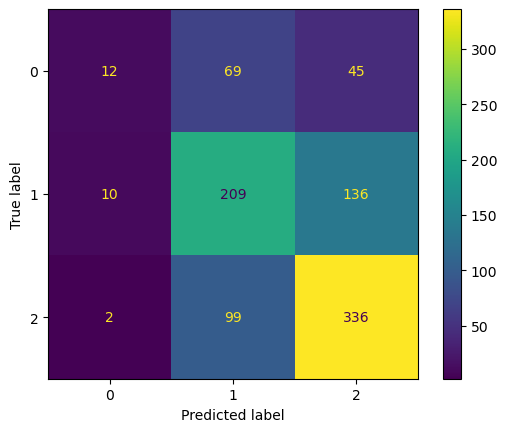

In [16]:
from sklearn import metrics

model = CatBoostClassifier(depth = 3, iterations = 1500, l2_leaf_reg = 3, learning_rate = 0.01, verbose=False)
model.fit(x_train_white, y_train_white)
y_pred_test = model.predict(x_test_white)
y_pred_train = model.predict(x_train_white)

confusion_matrix = metrics.confusion_matrix(y_test_white, y_pred_test)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=[0, 1, 2])

cm_display.plot()
plt.show()

Вывод из этого нотбука:
- Возможно у нас мало фичей, из-за чего модели не могут хорошо обучиться. Это можно было заметить после того, как я добавл 2 фичи, f1-score вырос у каждлй модели на ~0.05 единиц. Есть предположение, что с ростом фич, получится получить хорошую модель (потому что логистическая регрессия показала себя действительно хорошо, со скором как у катбуста, но при этом на трейне результаты гораздо хуже)
- Хочется избавиться от разделения на белого и черного игрока. Для этого нужно придумать новые фичи и собрать правильный датасет. В таком случае можем увеличить наш датасет в 2! раза